# **Assignment 7 - Perform different operations on Images**

**Name -** Devanshee Gupta \
**Scholar No.-** 25P02F1001


## **1. Import necessary libraries**

In [ ]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

## **2. Load and display the image**

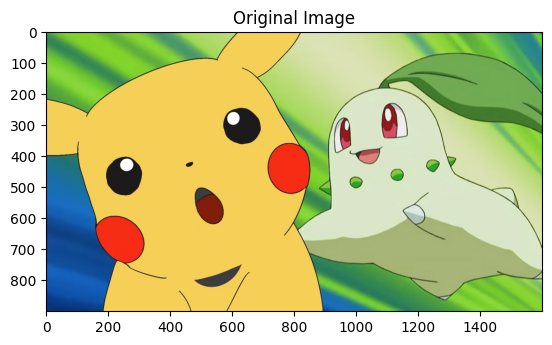

In [ ]:
image_path = "/content/pichi.png"

try:
    # Load image using PIL
    img_pil = Image.open(image_path)

    # Convert PIL image to NumPy array (OpenCV format)
    # PIL reads as RGB, OpenCV expects BGR for many operations,
    # so convert explicitly
    img = np.array(img_pil.convert('RGB'))
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR) # Convert RGB to BGR for OpenCV processing if needed

    # Check if image was loaded and converted successfully
    if img is None or img.size == 0:
        print("Error: Image could not be loaded or converted.")
    else:
        # OpenCV loads images in BGR format; convert to RGB for accurate display with Matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display the image
        plt.imshow(img_rgb)
        plt.title("Original Image")
        plt.show()
except FileNotFoundError:
    print(f"Error: Image not found at {image_path}. Please check the path and filename.")
except Exception as e:
    print(f"An unexpected error occurred while loading or processing the image: {e}")

## **3. Grayscaling**

Converting an image to grayscale reduces the number of channels from three (RGB) to one, simplifying computation

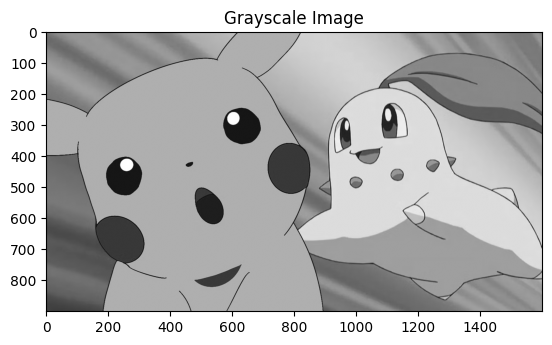

In [ ]:
# Convert the RGB image to grayscale using OpenCV
gray_image = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)

plt.imshow(gray_image, cmap='gray') # Use cmap='gray' for grayscale images
plt.title("Grayscale Image")
plt.show()


## **4. Resizing and Scaling**

Changing image dimensions is a common preprocessing step to ensure uniform input size for machine learning models.

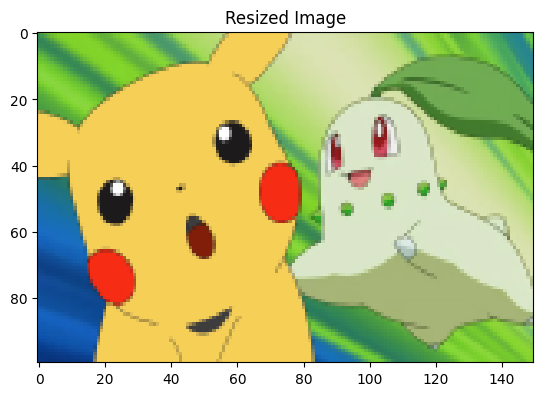

In [ ]:
# Define new dimensions (width, height)
width, height = 150, 100
resized_image = cv2.resize(img_rgb, (width, height), interpolation=cv2.INTER_AREA)

plt.imshow(resized_image)
plt.title("Resized Image")
plt.show()


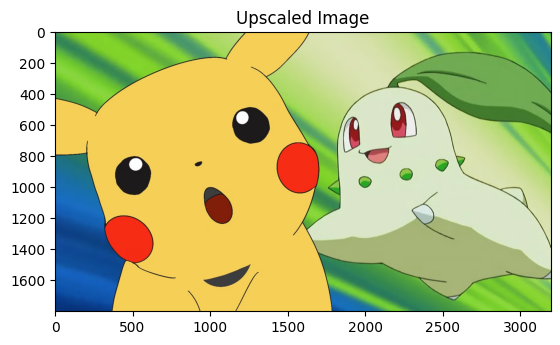

In [ ]:
# Resizing with a scaling factor (maintaining aspect ratio)
# INTER_CUBIC is good for enlarging (upscaling)
scale_factor = 2 # Double the size
upscaled_img = cv2.resize(img, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_CUBIC)

plt.imshow(cv2.cvtColor(upscaled_img, cv2.COLOR_BGR2RGB))
plt.title("Upscaled Image")
plt.show()

## **5. Rotation**

Rotating an image is a geometric transformation often used in data augmentation to create more training data.

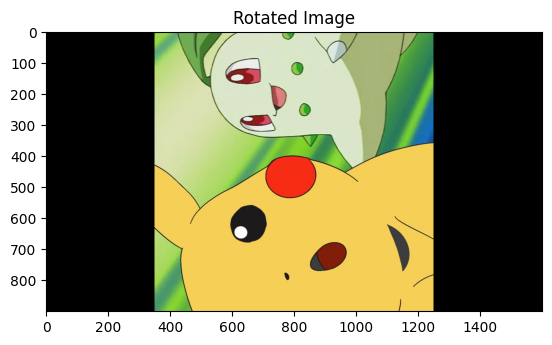

In [ ]:
# Get image dimensions
h, w = img_rgb.shape[:2]
# Define rotation matrix (center, angle (degrees), scale)
rotation_matrix = cv2.getRotationMatrix2D((w/2, h/2), 90, 1) # Rotate 90 degrees anti-clockwise

# Apply the rotation
rotated_image = cv2.warpAffine(img_rgb, rotation_matrix, (w, h))

plt.imshow(rotated_image)
plt.title("Rotated Image")
plt.show()


## **6. Data Augmentation**

This is a critical technique in deep learning to artificially expand the training dataset by applying various transformations, which improves model robustness and generalization.

* Geometric Transformations: Random rotations, flips, shifts, zooms, and perspective skewing.
* Color Space Transformations: Adjustments to brightness, contrast, saturation, and hue (color jitter).
* Adding Noise/Blur: Introducing Gaussian noise or blurring to simulate real-world conditions and prevent overfitting.

**Example (Random Horizontal Flip):**


In [ ]:
import tensorflow as tf

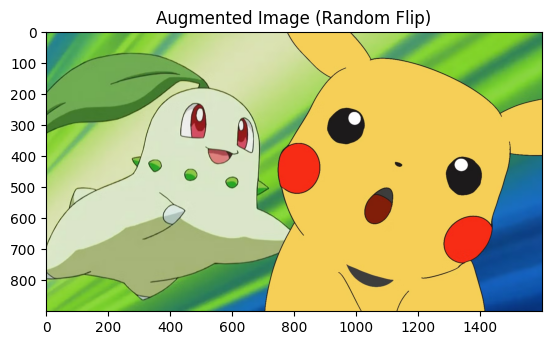

In [ ]:
# Apply a random horizontal flip (50% chance)
augmented_image = tf.image.random_flip_left_right(img_rgb)

plt.imshow(augmented_image.numpy())
plt.title("Augmented Image (Random Flip)")
plt.show()

## **7. Normalization**


Pixel values are divided by the maximum possible intensity value (usually 255 for standard 8-bit images). This scales every pixel to a float value between 0.0 and 1.0.

In [ ]:
print(f"Original Max Pixel Value: {img.max()}")

# Normalize by dividing all pixels by 255.0
normalized_img = img.astype('float32') / 255.0

print(f"Normalized Max Pixel Value: {normalized_img.max()}")


Original Max Pixel Value: 255
Normalized Max Pixel Value: 1.0


## **8. Assignment Summary**

This assignment demonstrated various fundamental image processing operations using OpenCV, Matplotlib, PIL, and TensorFlow:

*   **Loading and Displaying Images:** Handled different image formats and converted between PIL and OpenCV formats for display.
*   **Grayscaling:** Converted a color image to grayscale.
*   **Resizing and Scaling:** Resized images to specific dimensions and scaled them while maintaining aspect ratio.
*   **Rotation:** Performed geometric rotation of an image.
*   **Data Augmentation:** Showcased a basic data augmentation technique (random horizontal flip) using TensorFlow.
*   **Normalization:** Normalized pixel values to a 0-1 range for machine learning readiness.

---